# Thermal History and Trajectory of Molten Metal Droplets

## Coupled Droplet Movement, Cooling and Solidification

This notebook solves the coupled system of ordinary differential equations (ODEs) governing
the **flight dynamics** and **thermal evolution** of a molten metal droplet falling through
an inert gas atmosphere (e.g. during gas atomisation). The solver used is
`scipy.integrate.solve_ivp` with the **RK45** (Dormand–Prince) adaptive-step method.

### Physical Phenomena Modelled

| Phenomenon | Model / Correlation |
|---|---|
| Gravity + buoyancy | Archimedes (constant $\rho_{\text{alloy}}$, ideal-gas $\rho_{\text{gas}}$) |
| Aerodynamic drag | Schiller–Naumann correlation for $C_d(Re)$ |
| Convective heat loss | Ranz–Marshall correlation for $Nu(Re, Pr)$ |
| Radiative heat loss | Stefan–Boltzmann with constant emissivity $\varepsilon$ |
| Latent heat of solidification | Effective specific heat ($c_{p,\text{eff}}$) in the mushy zone |
| Gas transport properties | Sutherland's law for $\mu(T)$; power-law for $k(T)$ |

---

## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Nicer plots
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 — Physical Constants

In [2]:
g       = 9.81          # gravitational acceleration  [m/s²]
sigma   = 5.67e-8       # Stefan-Boltzmann constant   [W/(m²·K⁴)]
R_UNIV  = 8.314         # universal gas constant       [J/(mol·K)]
P_ATM   = 101_325       # atmospheric pressure         [Pa]

## 3 — Material & Gas Databases

### 3.1 Alloy data

Each alloy entry contains:

| Symbol | Quantity | Unit |
|--------|----------|------|
| `density` | Density (assumed constant, liquid/bulk) | kg/m³ |
| `liquidus` / `solidus` | Liquidus / Solidus temperature | K |
| `latent_heat` | Latent heat of fusion | J/kg |
| `cp_liquid` / `cp_solid` | Specific heat capacity (liquid / solid) | J/(kg·K) |
| `emissivity` | Total hemispherical emissivity | — |

In [3]:
ALLOYS = {
    "AlCu4.5": {
        "name": "AlCu4.5 (Aluminium-Copper)",
        "density": 2800, "liquidus": 923, "solidus": 843,
        "latent_heat": 395_000, "cp_liquid": 1100, "cp_solid": 900,
        "emissivity": 0.25,
    },
    "CuSn6": {
        "name": "CuSn6 (Bronze)",
        "density": 8860, "liquidus": 1323, "solidus": 1183,
        "latent_heat": 210_000, "cp_liquid": 450, "cp_solid": 380,
        "emissivity": 0.55,
    },
    "SS316L": {
        "name": "Stainless Steel 316L",
        "density": 7900, "liquidus": 1730, "solidus": 1670,
        "latent_heat": 260_000, "cp_liquid": 800, "cp_solid": 500,
        "emissivity": 0.85,
    },
    "Ti64": {
        "name": "Titanium Ti-6Al-4V",
        "density": 4420, "liquidus": 1928, "solidus": 1878,
        "latent_heat": 286_000, "cp_liquid": 830, "cp_solid": 730,
        "emissivity": 0.70,
    },
    "IN718": {
        "name": "Inconel 718",
        "density": 8190, "liquidus": 1610, "solidus": 1533,
        "latent_heat": 227_000, "cp_liquid": 600, "cp_solid": 435,
        "emissivity": 0.80,
    },
}

### 3.2 Gas data

Transport properties are evaluated at the **film temperature** $T_f = (T_{\text{droplet}} + T_{\text{gas}}) / 2$.

* **Density** — ideal gas law:  
  $\rho_{\text{gas}} = \dfrac{p\,M}{R\,T_f}$

* **Dynamic viscosity** — Sutherland's law:  
  $\mu = \mu_{\text{ref}}\left(\dfrac{T_f}{T_{\text{ref}}}\right)^{3/2}
  \dfrac{T_{\text{ref}} + S}{T_f + S}$

* **Thermal conductivity** — power-law approximation:  
  $k = k_{\text{ref}}\left(\dfrac{T_f}{T_{\text{ref}}}\right)^{0.7}$

In [4]:
GAS_DATA = {
    "Nitrogen": {"molar_mass": 0.028, "mu_ref": 1.78e-5, "k_ref": 0.026,
                 "sutherland_S": 111, "T_ref": 300, "cp": 1040},
    "Argon":    {"molar_mass": 0.0399, "mu_ref": 2.26e-5, "k_ref": 0.0177,
                 "sutherland_S": 144, "T_ref": 300, "cp": 520},
    "Helium":   {"molar_mass": 0.004, "mu_ref": 1.99e-5, "k_ref": 0.152,
                 "sutherland_S": 79,  "T_ref": 300, "cp": 5190},
}


def gas_properties(gas_name: str, T_film: float) -> dict:
    """
    Evaluate gas density, viscosity, thermal conductivity and cp
    at the film temperature T_film [K].
    """
    gas = GAS_DATA[gas_name]
    rho = (P_ATM * gas["molar_mass"]) / (R_UNIV * T_film)
    mu  = (gas["mu_ref"]
           * (T_film / gas["T_ref"]) ** 1.5
           * (gas["T_ref"] + gas["sutherland_S"])
           / (T_film + gas["sutherland_S"]))
    k   = gas["k_ref"] * (T_film / gas["T_ref"]) ** 0.7
    return {"rho": rho, "mu": mu, "k": k, "cp": gas["cp"]}

## 4 — Empirical Correlations

### 4.1 Drag coefficient — Schiller–Naumann

$$
C_d = \begin{cases}
\dfrac{24}{Re}\bigl(1 + 0.15\,Re^{\,0.687}\bigr) & Re < 1000 \\[6pt]
0.44 & Re \geq 1000
\end{cases}
$$

### 4.2 Nusselt number — Ranz–Marshall

$$
Nu = 2 + 0.6\,Re^{\,0.5}\,Pr^{\,1/3}
$$

In [5]:
def drag_coefficient(Re: float) -> float:
    """Schiller-Naumann drag correlation for a sphere."""
    if Re <= 0:
        return 0.0
    if Re < 1000:
        return (24.0 / Re) * (1.0 + 0.15 * Re ** 0.687)
    return 0.44


def nusselt_ranz_marshall(Re: float, Pr: float) -> float:
    """Ranz-Marshall correlation for convective heat transfer from a sphere."""
    return 2.0 + 0.6 * Re ** 0.5 * Pr ** (1.0 / 3.0)

## 5 — Governing Equations (ODE System)

We solve for the state vector $\mathbf{y} = [y,\; v,\; T]$ where

| Variable | Meaning | Unit |
|----------|---------|------|
| $y$ | Vertical fall distance (positive downward) | m |
| $v$ | Droplet velocity (positive downward) | m/s |
| $T$ | Droplet temperature (lumped, Biot ≪ 1) | K |

### 5.1 Equation of motion

$$
\frac{\mathrm{d}v}{\mathrm{d}t}
= \underbrace{g\!\left(1 - \frac{\rho_{\text{gas}}}{\rho_{\text{alloy}}}\right)}_{\text{gravity – buoyancy}}
- \underbrace{\frac{F_{\text{drag}}}{m}}_{\text{aerodynamic drag}}
$$

where the drag force on the sphere is

$$
F_{\text{drag}} = \tfrac{1}{2}\,\rho_{\text{gas}}\,v^2\,C_d\,A_{\text{surface}}
$$

and $A_{\text{surface}} = \pi D_p^2$ is the sphere surface area.

### 5.2 Energy equation

$$
\frac{\mathrm{d}T}{\mathrm{d}t}
= - \frac{6}{D_p\,\rho_{\text{alloy}}\,c_{p,\text{eff}}}
\Big[\underbrace{h\,(T - T_{\text{gas}})}_{\text{convection}}
+ \underbrace{\varepsilon\,\sigma\,(T^4 - T_{\text{gas}}^4)}_{\text{radiation}}\Big]
$$

### 5.3 Effective specific heat (mushy-zone model)

To capture the **latent heat** $L$ released during solidification without
an enthalpy method or phase-change tracking, we boost $c_p$ in the
mushy zone ($T_{\text{solidus}} \le T \le T_{\text{liquidus}}$):

$$
c_{p,\text{eff}} = \begin{cases}
c_{p,L} & T > T_{\text{liquidus}} \\[4pt]
\dfrac{c_{p,L} + c_{p,S}}{2} + \dfrac{L}{T_{\text{liquidus}} - T_{\text{solidus}}}
& T_{\text{solidus}} \le T \le T_{\text{liquidus}} \\[4pt]
c_{p,S} & T < T_{\text{solidus}}
\end{cases}
$$

This simple approach *spreads* the latent-heat release uniformly across
the solidification interval — a standard technique in lumped-capacitance
droplet models.

In [6]:
def effective_cp(T, alloy):
    """
    Return the effective specific heat capacity [J/(kg·K)].
    In the mushy zone the latent heat is distributed over
    the liquidus–solidus interval.
    """
    T_liq = alloy["liquidus"]
    T_sol = alloy["solidus"]
    if T > T_liq:
        return alloy["cp_liquid"]
    elif T >= T_sol:
        return ((alloy["cp_liquid"] + alloy["cp_solid"]) / 2.0
                + alloy["latent_heat"] / (T_liq - T_sol))
    else:
        return alloy["cp_solid"]

## 6 — ODE Right-Hand Side & Solver

We define the RHS function that `solve_ivp` will call at every
sub-step, and then wrap the solver call in a convenience function.

In [7]:
def droplet_ode(t, state, alloy, gas_name, dp, T_gas):
    """
    Right-hand side of the coupled ODE system.

    Parameters
    ----------
    t       : float          – current time [s]
    state   : array_like     – [y, v, T]
    alloy   : dict           – alloy property dictionary
    gas_name: str            – key into GAS_DATA
    dp      : float          – particle diameter [m]
    T_gas   : float          – ambient gas temperature [K]

    Returns
    -------
    list of float : [dy/dt, dv/dt, dT/dt]
    """
    y_pos, v, T = state
    rho_alloy = alloy["density"]

    # --- Geometric quantities (sphere) ---
    A_surface = np.pi * dp**2                    # surface area  [m²]
    volume    = (np.pi / 6.0) * dp**3            # volume        [m³]
    mass      = rho_alloy * volume               # mass          [kg]

    # --- Gas properties at film temperature ---
    T_film = 0.5 * (T + T_gas)
    gp = gas_properties(gas_name, T_film)

    # --- Dimensionless numbers ---
    Re = gp["rho"] * abs(v) * dp / gp["mu"]     # Reynolds number
    Pr = gp["cp"] * gp["mu"] / gp["k"]          # Prandtl number
    Cd = drag_coefficient(Re)
    Nu = nusselt_ranz_marshall(Re, Pr)

    # ===================== MOMENTUM EQUATION ======================
    F_gravity  = mass * g
    F_buoyancy = gp["rho"] * volume * g
    F_drag     = 0.5 * gp["rho"] * v**2 * Cd * A_surface
    dv_dt = (F_gravity - F_buoyancy - F_drag) / mass

    # ===================== ENERGY EQUATION ========================
    h_conv = Nu * gp["k"] / dp                   # convective HTC [W/(m²·K)]
    Q_conv = h_conv * A_surface * (T - T_gas)     # convective loss [W]
    Q_rad  = (alloy["emissivity"] * sigma
              * A_surface * (T**4 - T_gas**4))    # radiative loss  [W]

    cp_eff = effective_cp(T, alloy)
    dT_dt  = -(Q_conv + Q_rad) / (mass * cp_eff)

    # ===================== KINEMATICS =============================
    dy_dt = v

    return [dy_dt, dv_dt, dT_dt]

In [8]:
def run_simulation(
    alloy_key:   str   = "AlCu4.5",
    gas_name:    str   = "Argon",
    diameter_um: float = 500.0,
    T_initial:   float = 1200.0,
    v_initial:   float = 0.5,
    t_end:       float = 1.5,
    T_gas:       float = 300.0,
):
    """
    Solve the coupled droplet ODE system using RK45.

    Parameters
    ----------
    alloy_key   : str   – key into ALLOYS dictionary
    gas_name    : str   – 'Nitrogen', 'Argon', or 'Helium'
    diameter_um : float – droplet diameter [µm]
    T_initial   : float – initial droplet temperature [K]
    v_initial   : float – initial downward velocity [m/s]
    t_end       : float – total simulation time [s]
    T_gas       : float – ambient gas temperature [K]

    Returns
    -------
    sol : OdeResult  – scipy solution object
          sol.t      → time array
          sol.y[0]   → fall distance [m]
          sol.y[1]   → velocity [m/s]
          sol.y[2]   → temperature [K]
    alloy : dict     – the alloy properties used
    """
    alloy = ALLOYS[alloy_key]
    dp    = diameter_um * 1e-6                    # convert µm → m

    # Initial state: [y, v, T]
    y0 = [0.0, v_initial, T_initial]

    # Dense output at many evaluation points for smooth plots
    t_eval = np.linspace(0, t_end, 2000)

    sol = solve_ivp(
        fun      = droplet_ode,
        t_span   = (0, t_end),
        y0       = y0,
        method   = "RK45",
        t_eval   = t_eval,
        args     = (alloy, gas_name, dp, T_gas),
        rtol     = 1e-8,
        atol     = 1e-10,
        max_step = 1e-3,       # keep steps small near the mushy zone
    )

    if not sol.success:
        raise RuntimeError(f"Solver failed: {sol.message}")

    return sol, alloy

## 7 — Post-Processing Helpers

In [9]:
def compute_metrics(sol, alloy, T_initial):
    """
    Extract key engineering metrics from the solution.

    Returns a dict with:
      - solidification_dist : fall distance when T drops below solidus [m] or None
      - liquidus_dist       : fall distance when T drops below liquidus [m] or None
      - avg_cooling_rate    : average cooling rate in the mushy zone [K/s]
      - total_fall          : total fall distance at t_end [m]
      - final_velocity      : velocity at t_end [m/s]
      - final_temperature   : temperature at t_end [K]
    """
    t = sol.t
    y_pos, v, T = sol.y

    T_liq = alloy["liquidus"]
    T_sol = alloy["solidus"]

    # Check if we start already inside the mushy zone
    starts_in_mushy = (T_initial <= T_liq) and (T_initial >= T_sol)

    solidification_dist = None
    liquidus_dist       = None
    t_enter_mushy       = None
    t_exit_mushy        = None

    for i in range(len(t)):
        # Crossing liquidus from above
        if liquidus_dist is None and T[i] <= T_liq and not starts_in_mushy:
            liquidus_dist = y_pos[i]
            t_enter_mushy = t[i]

        # Inside mushy zone — keep updating exit time
        if T_sol <= T[i] <= T_liq:
            t_exit_mushy = t[i]

        # Crossing solidus from above
        if solidification_dist is None and T[i] <= T_sol:
            solidification_dist = y_pos[i]
            if liquidus_dist is None:
                liquidus_dist = y_pos[i]
            break

    # Average cooling rate in mushy zone
    avg_cooling_rate = 0.0
    if solidification_dist is not None:
        if starts_in_mushy:
            if t_exit_mushy and t_exit_mushy > 0:
                avg_cooling_rate = (T_initial - T_sol) / t_exit_mushy
        elif t_enter_mushy is not None and t_exit_mushy is not None:
            dt_mushy = t_exit_mushy - t_enter_mushy
            if dt_mushy > 0:
                avg_cooling_rate = (T_liq - T_sol) / dt_mushy

    return {
        "solidification_dist": solidification_dist,
        "liquidus_dist":       liquidus_dist,
        "avg_cooling_rate":    avg_cooling_rate,
        "total_fall":          y_pos[-1],
        "final_velocity":      v[-1],
        "final_temperature":   T[-1],
    }

## 8 — Plotting

In [10]:
def plot_results(sol, alloy, metrics):
    """
    Generate a three-panel figure:
      (a) Temperature vs. time   (with liquidus / solidus lines)
      (b) Velocity vs. time
      (c) Fall distance vs. time (with solidification distance marker)
    """
    t = sol.t
    y_pos, v, T = sol.y

    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
    fig.suptitle(
        f"{alloy['name']}  —  "
        f"$D_p$ = {sol.y[0][0]*0 + 0:.0f} … (see title below)",
        fontsize=13, fontweight="bold", y=0.98,
    )

    # --- (a) Temperature ---
    ax = axes[0]
    ax.plot(t, T, color="#e74c3c", linewidth=1.8, label="Droplet temperature")
    ax.axhline(alloy["liquidus"], ls="--", color="#3498db", lw=1, label="Liquidus")
    ax.axhline(alloy["solidus"],  ls="--", color="#e67e22", lw=1, label="Solidus")
    # shade mushy zone
    ax.axhspan(alloy["solidus"], alloy["liquidus"],
               alpha=0.08, color="orange", label="Mushy zone")
    ax.set_ylabel("Temperature  [K]")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title("(a) Thermal History", fontsize=11, loc="left")

    # --- (b) Velocity ---
    ax = axes[1]
    ax.plot(t, v, color="#3498db", linewidth=1.8)
    ax.set_ylabel("Velocity  [m/s]")
    ax.set_title("(b) Velocity", fontsize=11, loc="left")

    # --- (c) Fall distance ---
    ax = axes[2]
    ax.plot(t, y_pos, color="#2ecc71", linewidth=1.8, label="Fall distance")
    if metrics["solidification_dist"] is not None:
        ax.axhline(metrics["solidification_dist"], ls=":", color="#e74c3c",
                   lw=1, label=f"Solidified at {metrics['solidification_dist']:.2f} m")
    if metrics["liquidus_dist"] is not None:
        ax.axhline(metrics["liquidus_dist"], ls=":", color="#3498db",
                   lw=1, label=f"Liquidus at {metrics['liquidus_dist']:.2f} m")
    ax.set_ylabel("Fall Distance  [m]")
    ax.set_xlabel("Time  [s]")
    ax.legend(loc="upper left", fontsize=9)
    ax.set_title("(c) Position", fontsize=11, loc="left")

    fig.tight_layout()
    plt.show()
    return fig

## 9 — Run the Simulation

### 9.1 Default case: AlCu4.5 droplet in Argon

  Alloy             : AlCu4.5 (Aluminium-Copper)
  Total fall        : 1.871 m
  Final velocity    : 1.325 m/s
  Final temperature : 675.9 K
  Solidification at : 1.431 m
  Avg cooling rate  : 102 K/s


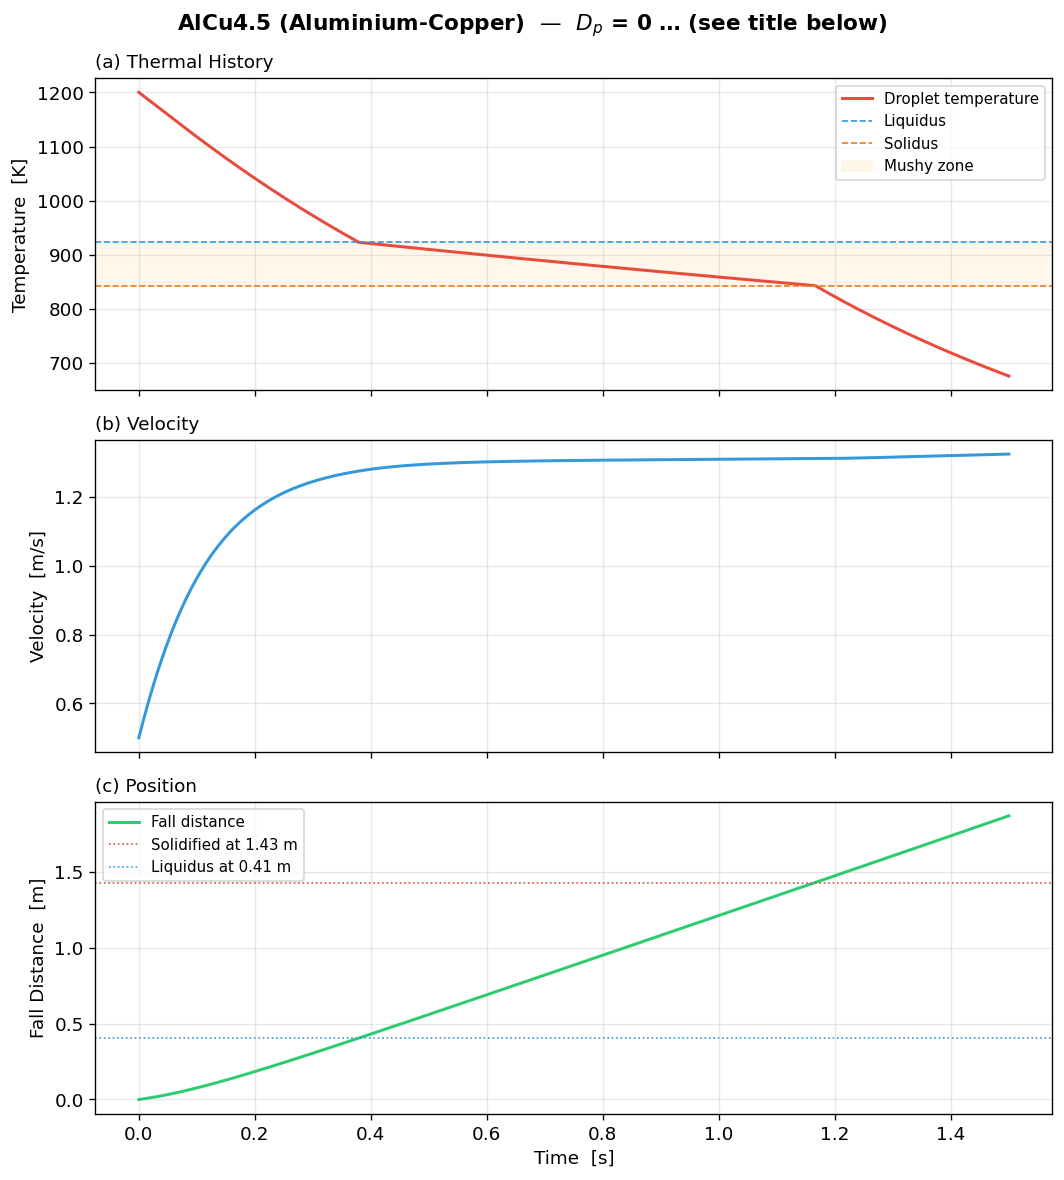

In [11]:
sol, alloy = run_simulation(
    alloy_key   = "AlCu4.5",
    gas_name    = "Argon",
    diameter_um = 500,
    T_initial   = 1200,
    v_initial   = 0.5,
    t_end       = 1.5,
    T_gas       = 300,
)

metrics = compute_metrics(sol, alloy, T_initial=1200)

print("=" * 50)
print(f"  Alloy             : {alloy['name']}")
print(f"  Total fall        : {metrics['total_fall']:.3f} m")
print(f"  Final velocity    : {metrics['final_velocity']:.3f} m/s")
print(f"  Final temperature : {metrics['final_temperature']:.1f} K")
if metrics["solidification_dist"]:
    print(f"  Solidification at : {metrics['solidification_dist']:.3f} m")
    print(f"  Avg cooling rate  : {metrics['avg_cooling_rate']:.0f} K/s")
else:
    print("  ⚠  Droplet did NOT fully solidify within the simulated time.")
print("=" * 50)

_ = plot_results(sol, alloy, metrics)

### 9.2 Parameter study: Effect of droplet diameter

Smaller droplets have a **larger surface-to-volume ratio** and therefore
cool much faster. We sweep $D_p$ from 100 µm to 1000 µm.

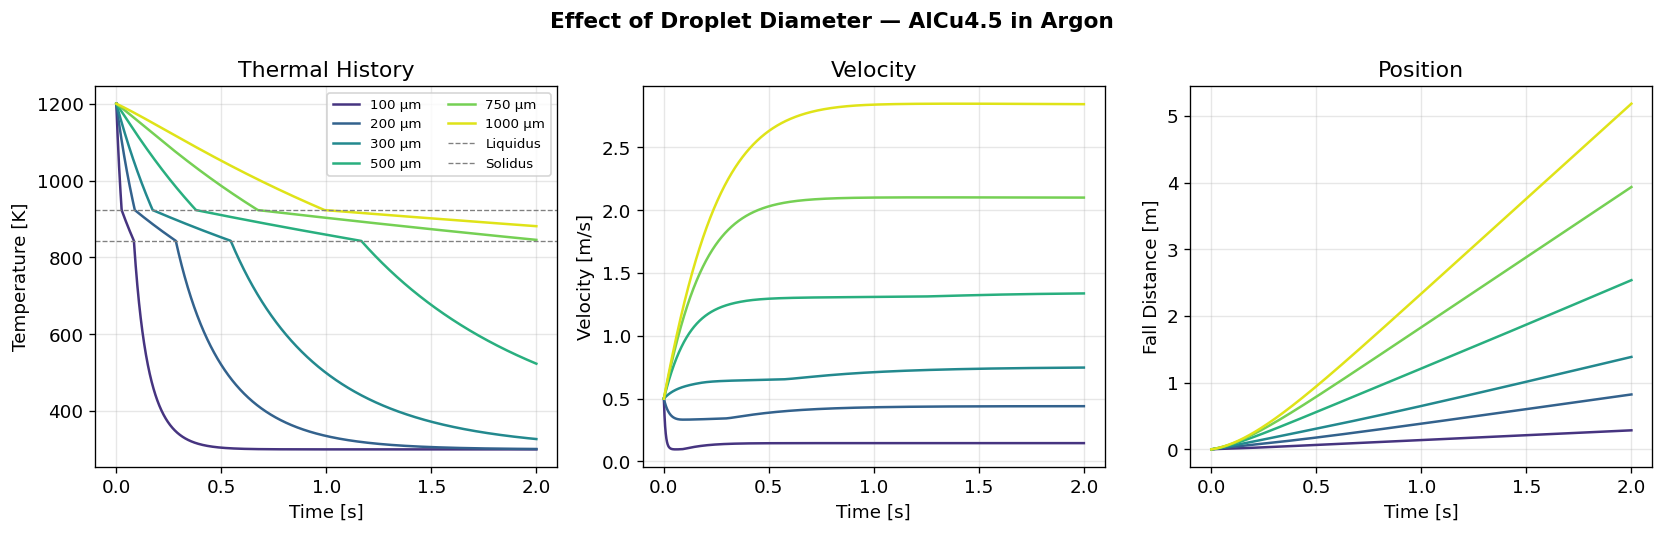

In [12]:
diameters = [100, 200, 300, 500, 750, 1000]   # µm

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
cmap = plt.cm.viridis(np.linspace(0.15, 0.95, len(diameters)))

for i, d in enumerate(diameters):
    sol, alloy = run_simulation(
        alloy_key="AlCu4.5", gas_name="Argon",
        diameter_um=d, T_initial=1200, v_initial=0.5,
        t_end=2.0, T_gas=300,
    )
    t = sol.t
    axes[0].plot(t, sol.y[2], color=cmap[i], lw=1.5, label=f"{d} µm")
    axes[1].plot(t, sol.y[1], color=cmap[i], lw=1.5)
    axes[2].plot(t, sol.y[0], color=cmap[i], lw=1.5)

axes[0].axhline(alloy["liquidus"], ls="--", color="grey", lw=0.8, label="Liquidus")
axes[0].axhline(alloy["solidus"],  ls="--", color="grey", lw=0.8, label="Solidus")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Thermal History")
axes[0].legend(fontsize=8, ncol=2)

axes[1].set_ylabel("Velocity [m/s]")
axes[1].set_title("Velocity")

axes[2].set_ylabel("Fall Distance [m]")
axes[2].set_title("Position")

for ax in axes:
    ax.set_xlabel("Time [s]")

fig.suptitle("Effect of Droplet Diameter — AlCu4.5 in Argon",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### 9.3 Parameter study: Effect of chamber gas

**Helium** has a much higher thermal conductivity ($k$) and specific heat
than Argon or Nitrogen, leading to significantly faster cooling.

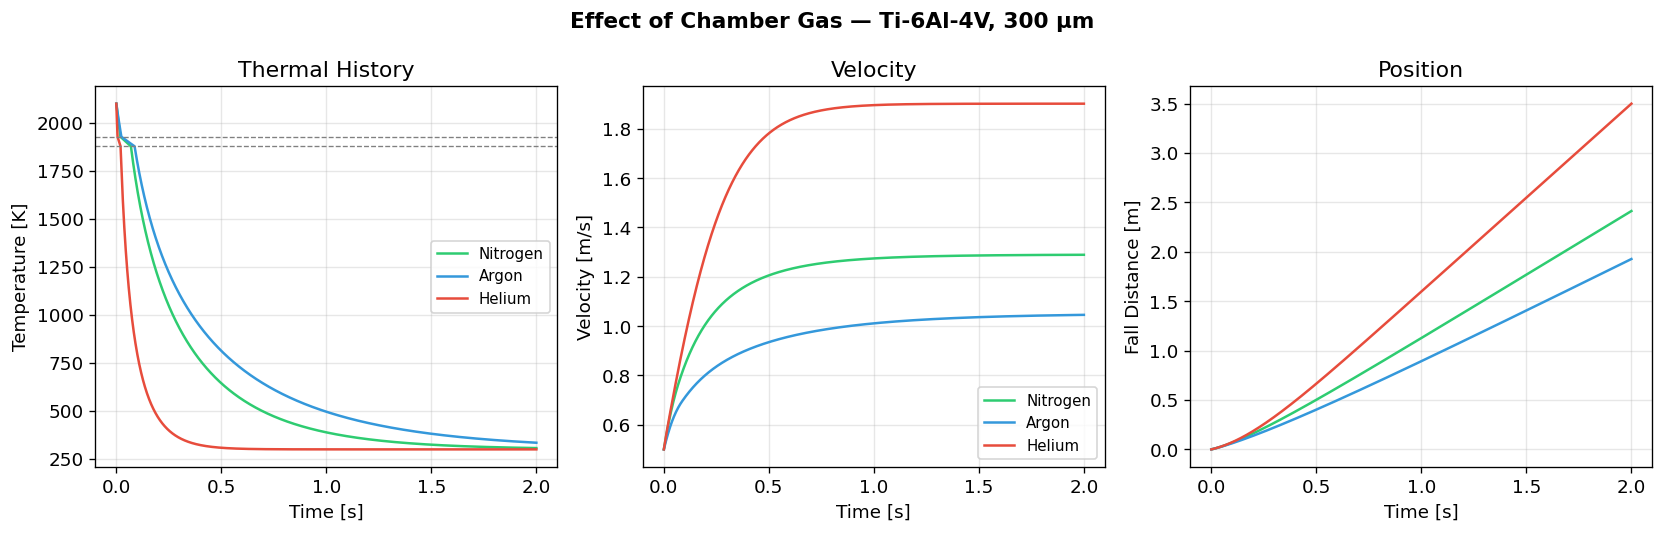

In [13]:
gases  = ["Nitrogen", "Argon", "Helium"]
colors = ["#2ecc71", "#3498db", "#e74c3c"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for gas, col in zip(gases, colors):
    sol, alloy = run_simulation(
        alloy_key="Ti64", gas_name=gas,
        diameter_um=300, T_initial=2100, v_initial=0.5,
        t_end=2.0, T_gas=300,
    )
    t = sol.t
    axes[0].plot(t, sol.y[2], color=col, lw=1.5, label=gas)
    axes[1].plot(t, sol.y[1], color=col, lw=1.5, label=gas)
    axes[2].plot(t, sol.y[0], color=col, lw=1.5, label=gas)

axes[0].axhline(alloy["liquidus"], ls="--", color="grey", lw=0.8)
axes[0].axhline(alloy["solidus"],  ls="--", color="grey", lw=0.8)
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Thermal History")
axes[0].legend(fontsize=9)

axes[1].set_ylabel("Velocity [m/s]")
axes[1].set_title("Velocity")
axes[1].legend(fontsize=9)

axes[2].set_ylabel("Fall Distance [m]")
axes[2].set_title("Position")

for ax in axes:
    ax.set_xlabel("Time [s]")

fig.suptitle("Effect of Chamber Gas — Ti-6Al-4V, 300 µm",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### 9.4 Comparison across alloys

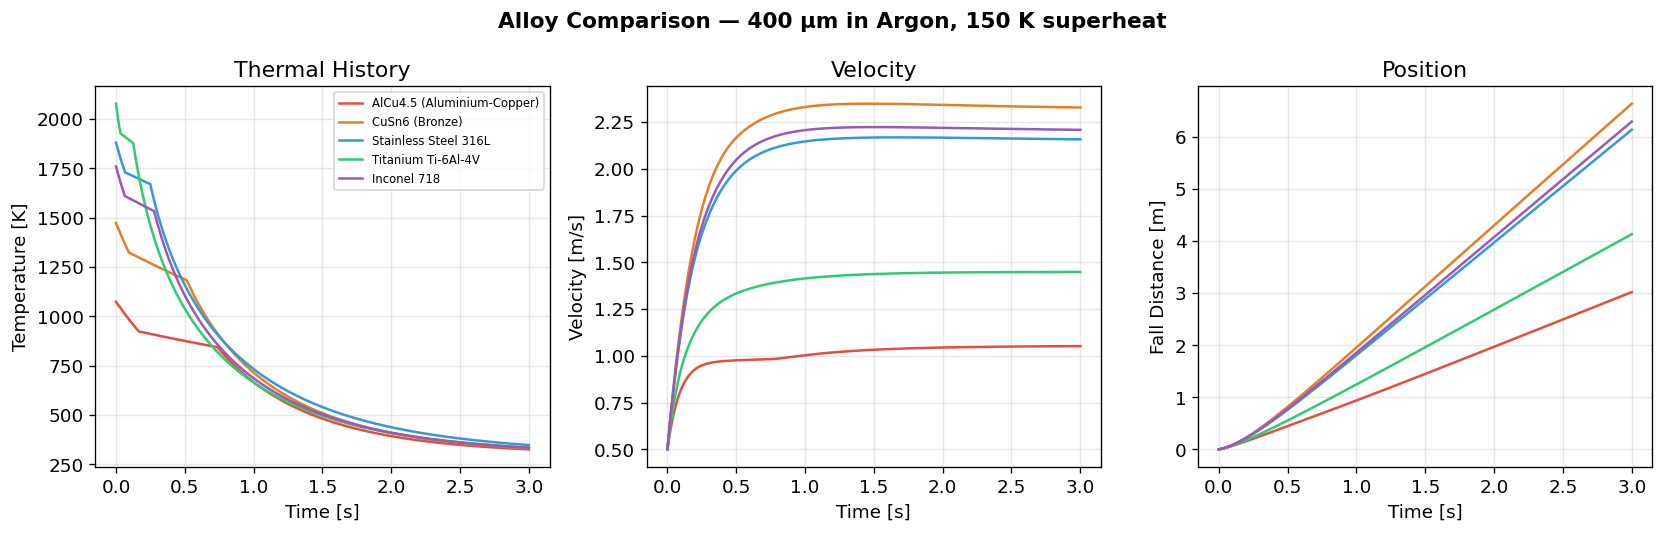

In [14]:
alloy_keys = ["AlCu4.5", "CuSn6", "SS316L", "Ti64", "IN718"]
alloy_colors = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71", "#9b59b6"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for key, col in zip(alloy_keys, alloy_colors):
    a = ALLOYS[key]
    T0 = a["liquidus"] + 150   # superheat of ~150 K
    sol, alloy = run_simulation(
        alloy_key=key, gas_name="Argon",
        diameter_um=400, T_initial=T0, v_initial=0.5,
        t_end=3.0, T_gas=300,
    )
    t = sol.t
    axes[0].plot(t, sol.y[2], color=col, lw=1.5, label=a["name"])
    axes[1].plot(t, sol.y[1], color=col, lw=1.5)
    axes[2].plot(t, sol.y[0], color=col, lw=1.5)

axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Thermal History")
axes[0].legend(fontsize=7, loc="upper right")

axes[1].set_ylabel("Velocity [m/s]")
axes[1].set_title("Velocity")

axes[2].set_ylabel("Fall Distance [m]")
axes[2].set_title("Position")

for ax in axes:
    ax.set_xlabel("Time [s]")

fig.suptitle("Alloy Comparison — 400 µm in Argon, 150 K superheat",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 10 — Summary Table for All Alloys

In [15]:
print(f"{'Alloy':<28} {'D [µm]':>7} {'T₀ [K]':>7} {'Sol. Dist [m]':>14} "
      f"{'Cool Rate [K/s]':>16} {'Fall [m]':>9} {'v_end [m/s]':>12}")
print("-" * 100)

for key in alloy_keys:
    a = ALLOYS[key]
    T0 = a["liquidus"] + 150
    sol, alloy = run_simulation(
        alloy_key=key, gas_name="Argon",
        diameter_um=400, T_initial=T0, v_initial=0.5,
        t_end=3.0, T_gas=300,
    )
    m = compute_metrics(sol, alloy, T0)
    sd = f"{m['solidification_dist']:.3f}" if m['solidification_dist'] else "—"
    cr = f"{m['avg_cooling_rate']:.0f}" if m['avg_cooling_rate'] else "—"
    print(f"{a['name']:<28} {400:>7} {T0:>7.0f} {sd:>14} "
          f"{cr:>16} {m['total_fall']:>9.3f} {m['final_velocity']:>12.3f}")

Alloy                         D [µm]  T₀ [K]  Sol. Dist [m]  Cool Rate [K/s]  Fall [m]  v_end [m/s]
----------------------------------------------------------------------------------------------------
AlCu4.5 (Aluminium-Copper)       400    1073          0.680              140     3.018        1.052
CuSn6 (Bronze)                   400    1473          0.850              334     6.633        2.328
Stainless Steel 316L             400    1880          0.299              328     6.134        2.157
Titanium Ti-6Al-4V               400    2078          0.100              546     4.129        1.449
Inconel 718                      400    1760          0.351              364     6.289        2.208


## 11 — Notes for Students

### Key assumptions and limitations

1. **Lumped capacitance** — The droplet temperature is uniform (no internal
   gradients). This is valid when the Biot number $Bi = h D_p / (6 k_{\text{alloy}}) \ll 1$,
   which generally holds for small metallic droplets with high thermal conductivity.

2. **Spherical shape** — The droplet is assumed to remain a perfect sphere
   throughout flight (no deformation, breakup, or oscillation).

3. **Constant alloy density** — Density is taken as constant; in reality it
   varies with temperature and phase fraction.

4. **No undercooling** — Solidification begins exactly at the liquidus temperature.
   Real alloys, especially at high cooling rates, can undercool significantly before
   nucleation occurs.

5. **No droplet interactions** — The model tracks a single isolated droplet.
   In a real atomisation process, neighbouring droplets modify the local gas flow
   and temperature field.